In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [7]:
# Make the corner plot for the MCMC results
system_name = '2M1134'
model_ver = 'sie'
mcmc_samples_path = f'./{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['accept', 'chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [8]:
samples

,accept,chi2,vel_disp,x,y,ellip,pa
0,accept,52.53043,332.0260,1.115581,1.651493,0.895387,43.35013
1,accept,53.28147,332.1055,1.115123,1.651100,0.895387,43.27163
2,reject,54.70980,332.1127,1.118665,1.651971,0.895404,43.30431
3,reject,76.99095,333.4554,1.114546,1.648107,0.895414,43.34315
4,reject,85.98347,333.6769,1.116482,1.649128,0.895394,43.31737
...,...,...,...,...,...,...,...
4996,reject,60.48383,331.8647,1.126711,1.632086,0.894263,43.54778
4997,reject,62.48344,331.0930,1.128045,1.635300,0.894344,43.58414
4998,reject,61.57537,331.6204,1.131978,1.627903,0.894220,43.55924
4999,reject,130.32820,333.9088,1.128686,1.637903,0.894219,43.56234


In [13]:
# Masked Samples with no accept column
masked_samples = samples[samples['accept'] == 'accept'].copy()
masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
masked_samples

array([[332.026    ,   1.115581 ,   1.651493 ,   0.8953869,  43.35013  ],
       [332.1055   ,   1.115123 ,   1.6511   ,   0.8953866,  43.27163  ],
       [332.2211   ,   1.114231 ,   1.653072 ,   0.8954174,  43.26689  ],
       ...,
       [332.0476   ,   1.131131 ,   1.636822 ,   0.8942551,  43.50487  ],
       [331.9939   ,   1.128863 ,   1.633116 ,   0.8942823,  43.56626  ],
       [331.6668   ,   1.130518 ,   1.630385 ,   0.8942828,  43.54807  ]])

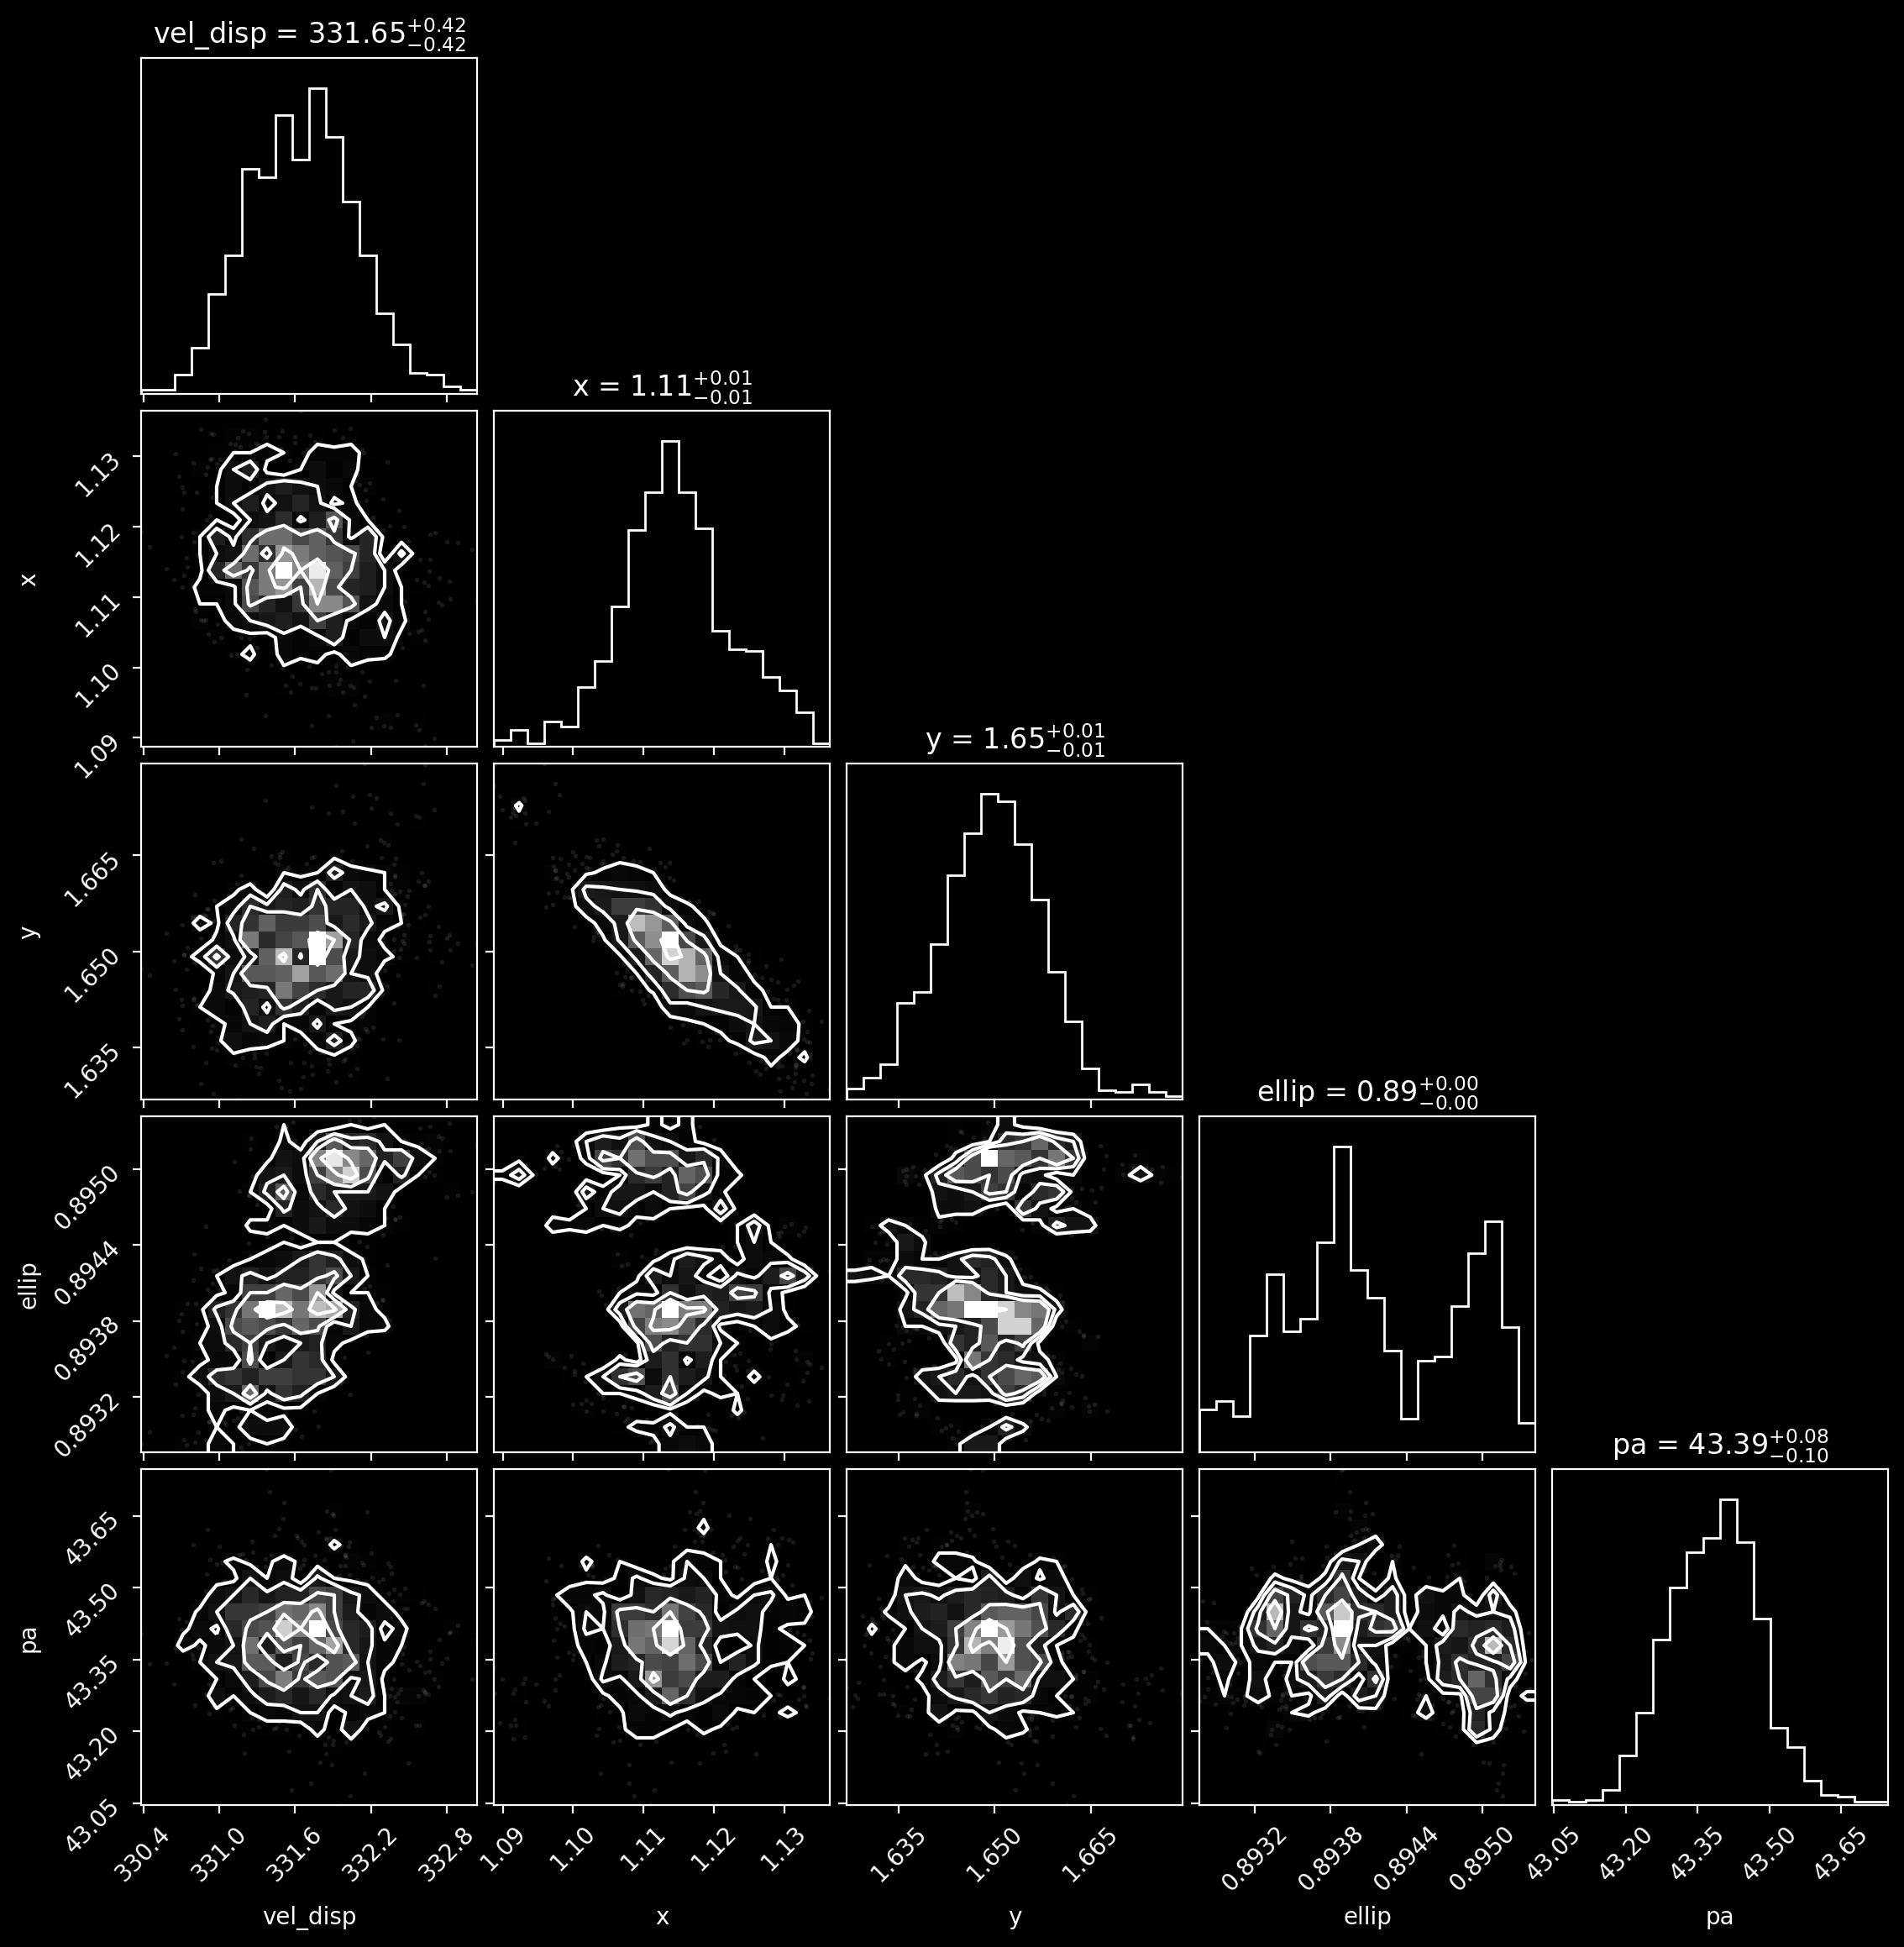

In [14]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'./{system_name}/mcmc/{model_ver}_corner.png')